In [0]:
df = spark.table("workspace.default.credit_companies")
display(df.limit(1000))

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,Rating,LatePayments,Default
C0001,,305,15,low,"0,38",SK,B,1,
C0002,47.59,14,14,low,0.47,CZ,AAA,2,no
C0003,NA,320,24,medium,0.7,PL,AAA,1,1
C0004,30.33,82,35,high,0.64,Other,CCC,3,0
C0005,"8,64",218,10,medium,"0,69",PL,AA,,1
C0006,"8,64",341,14,medium,0.06,SK,A,3,0
C0007,3.85,266,3,high,"0,25",Other,BB,4,0
C0008,43.44,481,20,low,"0,65",PL,,2,yes
C0009,30.45,151,12,low,0.49,,CCC,1,0
C0010,"35,7",83,21,low,"0,05",PL,B,4,1


In [0]:
df.printSchema()
print("rows:", df.count())

root
 |-- CompanyID: string (nullable = true)
 |-- Revenue: string (nullable = true)
 |-- Employees: string (nullable = true)
 |-- YearsActive: string (nullable = true)
 |-- IndustryRisk: string (nullable = true)
 |-- DebtRatio: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- LatePayments: string (nullable = true)
 |-- Default: string (nullable = true)

rows: 1000


In [0]:
#zamienianie na nulle za pomocą funkcji różnych dziwnych wartości

from pyspark.sql import functions as F

na_values = ["NA", "na", "", "null", " ", "-", "--", "?", "??", "null"]

def clean_numeric(col):
    return (
        F.when(F.col(col).isin(na_values), None)
         .when(F.col(col).rlike("[a-zA-Z]"), None)
         .otherwise(F.regexp_replace(F.col(col), ",", ".").cast("double"))
    )

df = (
    df
    .withColumn("Revenue", clean_numeric("Revenue"))
    .withColumn("YearsActive", clean_numeric("YearsActive"))
    .withColumn("DebtRatio", clean_numeric("DebtRatio"))
    .withColumn("Employees", clean_numeric("Employees"))
    .withColumn("LatePayments", clean_numeric("LatePayments"))
)

In [0]:
display(df.limit(50))

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,Rating,LatePayments,Default
C0001,null,305.0,15.0,low,0.38,SK,B,1.0,
C0002,47.59,14.0,14.0,low,0.47,CZ,AAA,2.0,no
C0003,null,320.0,24.0,medium,0.7,PL,AAA,1.0,1
C0004,30.33,82.0,35.0,high,0.64,Other,CCC,3.0,0
C0005,8.64,218.0,10.0,medium,0.69,PL,AA,null,1
C0006,8.64,341.0,14.0,medium,0.06,SK,A,3.0,0
C0007,3.85,266.0,3.0,high,0.25,Other,BB,4.0,0
C0008,43.44,481.0,20.0,low,0.65,PL,,2.0,yes
C0009,30.45,151.0,12.0,low,0.49,,CCC,1.0,0
C0010,35.7,83.0,21.0,low,0.05,PL,B,4.0,1


In [0]:
#przeglądamy wartości w kolumnie default
from pyspark.sql import functions as F

display(
    df.groupBy(F.col("Default").cast("string").alias("Default_raw"))
      .count()
      .orderBy(F.desc("count"))
)


Default_raw,count
0,659
1,110
no,88
yes,81
,30
NA,28
maybe,4


In [0]:
from pyspark.sql import functions as F

df = (
    df
    .withColumn("Default_raw", F.col("Default").cast("string"))
    .withColumn("Default_norm", F.lower(F.trim(F.col("Default_raw"))))
    .withColumn(
        "Default_clean",
        F.when(F.col("Default_norm").isin("1", "yes"), F.lit(1))
         .when(F.col("Default_norm").isin("0", "no"),  F.lit(0))
         .otherwise(F.lit(None).cast("int"))
    )
)


In [0]:
display(
    df.groupBy("Default_raw", "Default_norm", "Default_clean")
      .count()
      .orderBy(F.desc("count"))
)

Default_raw,Default_norm,Default_clean,count
0,0,0,659
1,1,1,110
no,no,0,88
yes,yes,1,81
,,null,30
NA,na,null,28
maybe,maybe,null,4


In [0]:
display(
    df.filter(F.col("Default_clean").isNull())
      .select("CompanyID", "Default_raw", "Default_norm", "Default_clean")
      .limit(200)
)

CompanyID,Default_raw,Default_norm,Default_clean
C0001,,,null
C0031,NA,na,null
C0032,,,null
C0040,,,null
C0053,maybe,maybe,null
C0078,NA,na,null
C0082,,,null
C0123,NA,na,null
C0129,NA,na,null
C0138,,,null


In [0]:
df_model = (
    df.filter(F.col("Default_clean").isNotNull())
      .drop("Default")
      .withColumnRenamed("Default_clean", "Default")
      .drop("Default_raw", "Default_norm")
)

In [0]:
display(df_model.groupBy("Default").count().orderBy("Default"))

Default,count
0,747
1,191


In [0]:
df_model.columns

['CompanyID',
 'Revenue',
 'Employees',
 'YearsActive',
 'IndustryRisk',
 'DebtRatio',
 'Region',
 'Rating',
 'LatePayments',
 'Default']

In [0]:
display(df_model)

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,Rating,LatePayments,Default
C0002,47.59,14.0,14.0,low,0.47,CZ,AAA,2.0,0
C0003,null,320.0,24.0,medium,0.7,PL,AAA,1.0,1
C0004,30.33,82.0,35.0,high,0.64,Other,CCC,3.0,0
C0005,8.64,218.0,10.0,medium,0.69,PL,AA,null,1
C0006,8.64,341.0,14.0,medium,0.06,SK,A,3.0,0
C0007,3.85,266.0,3.0,high,0.25,Other,BB,4.0,0
C0008,43.44,481.0,20.0,low,0.65,PL,,2.0,1
C0009,30.45,151.0,12.0,low,0.49,,CCC,1.0,0
C0010,35.7,83.0,21.0,low,0.05,PL,B,4.0,1
C0011,2.01,217.0,18.0,medium,0.77,PL,CCC,1.0,1


In [0]:
# usuwam zbędne spacje
from pyspark.sql import functions as F

df_model = (
    df_model
    .withColumn("IndustryRisk", F.regexp_replace(F.trim(F.col("IndustryRisk")), r"\s+", " "))
    .withColumn("Region",       F.regexp_replace(F.trim(F.col("Region")),       r"\s+", " "))
)

In [0]:
display(
    df_model.groupBy("Region").count().orderBy(F.desc("count"))
)

display(
    df_model.groupBy("IndustryRisk").count().orderBy(F.desc("count"))
)

Region,count
PL,430
DE,174
Other,89
SK,87
CZ,83
NA,35
,28
?,6
unknown,6


IndustryRisk,count
low,355
medium,351
high,160
NA,34
,27
unknown,8
?,3


In [0]:
from pyspark.sql import functions as F

# normalizacja whitespace + case
df_model = (
    df_model
    .withColumn("Region", F.upper(F.regexp_replace(F.trim(F.col("Region")), r"\s+", " ")))
    .withColumn("IndustryRisk", F.lower(F.regexp_replace(F.trim(F.col("IndustryRisk")), r"\s+", " ")))
)

# REGION: śmieci -> Other
df_model = df_model.withColumn(
    "Region",
    F.when(
        F.col("Region").isNull() |
        (F.col("Region") == "") |
        (F.col("Region").isin("NA", "UNKNOWN", "?", "N/A")),
        F.lit("OTHER")
    ).otherwise(F.col("Region"))
)

# INDUSTRYRISK: śmieci -> medium (neutral)
df_model = df_model.withColumn(
    "IndustryRisk",
    F.when(
        F.col("IndustryRisk").isNull() |
        (F.col("IndustryRisk") == "") |
        (F.col("IndustryRisk").isin("na", "unknown", "?", "n/a")),
        F.lit("medium")
    ).otherwise(F.col("IndustryRisk"))
)
display(df_model.groupBy("Region").count().orderBy(F.desc("count")))
display(df_model.groupBy("IndustryRisk").count().orderBy(F.desc("count")))


Region,count
PL,430
DE,174
OTHER,164
SK,87
CZ,83


IndustryRisk,count
medium,423
low,355
high,160


In [0]:
display(df_model)

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,Rating,LatePayments,Default
C0002,47.59,14.0,14.0,low,0.47,CZ,AAA,2.0,0
C0003,null,320.0,24.0,medium,0.7,PL,AAA,1.0,1
C0004,30.33,82.0,35.0,high,0.64,OTHER,CCC,3.0,0
C0005,8.64,218.0,10.0,medium,0.69,PL,AA,null,1
C0006,8.64,341.0,14.0,medium,0.06,SK,A,3.0,0
C0007,3.85,266.0,3.0,high,0.25,OTHER,BB,4.0,0
C0008,43.44,481.0,20.0,low,0.65,PL,,2.0,1
C0009,30.45,151.0,12.0,low,0.49,OTHER,CCC,1.0,0
C0010,35.7,83.0,21.0,low,0.05,PL,B,4.0,1
C0011,2.01,217.0,18.0,medium,0.77,PL,CCC,1.0,1


In [0]:
from pyspark.sql import functions as F

df_model = df_model.withColumn(
    "Rating",
    F.upper(F.regexp_replace(F.trim(F.col("Rating").cast("string")), r"\s+", " "))
)
display(
    df_model.groupBy("Rating")
            .count()
            .orderBy(F.desc("count"))
)

Rating,count
AA,139
BB,132
CCC,128
AAA,125
A,123
BBB,116
B,103
NA,32
,25
?,8


In [0]:
from pyspark.sql import functions as F

rating_map = {
    "AAA": 7, "AA": 6, "A": 5,
    "BBB": 4, "BB": 3, "B": 2,
    "CCC": 1
}

mapping_expr = F.create_map(
    *[F.lit(x) for x in sum(rating_map.items(), ())]
)

df_model = df_model.withColumn(
    "RatingScore",
    mapping_expr[F.col("Rating")]
)

# braki -> mediana (BBB = 4)
df_model = df_model.withColumn(
    "RatingScore",
    F.coalesce(F.col("RatingScore"), F.lit(4))
)

In [0]:
display(
    df_model.groupBy("Rating", "RatingScore")
            .count()
            .orderBy("RatingScore", ascending=False)
)

Rating,RatingScore,count
AAA,7,125
AA,6,139
A,5,123
UNKNOWN,4,7
?,4,8
,4,25
BBB,4,116
NA,4,32
BB,3,132
B,2,103


In [0]:
df_model = df_model.drop("Rating")

In [0]:
display(df_model)

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,LatePayments,Default,RatingScore
C0002,47.59,14.0,14.0,low,0.47,CZ,2.0,0,7
C0003,null,320.0,24.0,medium,0.7,PL,1.0,1,7
C0004,30.33,82.0,35.0,high,0.64,OTHER,3.0,0,1
C0005,8.64,218.0,10.0,medium,0.69,PL,null,1,6
C0006,8.64,341.0,14.0,medium,0.06,SK,3.0,0,5
C0007,3.85,266.0,3.0,high,0.25,OTHER,4.0,0,3
C0008,43.44,481.0,20.0,low,0.65,PL,2.0,1,4
C0009,30.45,151.0,12.0,low,0.49,OTHER,1.0,0,1
C0010,35.7,83.0,21.0,low,0.05,PL,4.0,1,2
C0011,2.01,217.0,18.0,medium,0.77,PL,1.0,1,1


In [0]:
from pyspark.sql import functions as F

display(
    df_model.select([
        F.count(F.when(F.col(c).isNull(), 1)).alias(c)
        for c in df_model.columns
    ])
)

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,LatePayments,Default,RatingScore
0,66,70,67,0,75,0,70,0,0


In [0]:
from pyspark.sql import functions as F

num_cols = [
    "Revenue",
    "Employees",
    "YearsActive",
    "DebtRatio",
    "LatePayments"
]

for c in num_cols:
    median = df_model.approxQuantile(c, [0.5], 0.01)[0]
    print(f"{c} median =", median)
    df_model = df_model.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit(median)).otherwise(F.col(c))
    )

Revenue median = 25.14
Employees median = 264.0
YearsActive median = 20.0
DebtRatio median = 0.5
LatePayments median = 2.0


In [0]:
from pyspark.sql import functions as F
display(
    df_model.select([
        F.count(F.when(F.col(c).isNull(), 1)).alias(c)
        for c in df_model.columns
    ])
)

CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,LatePayments,Default,RatingScore
0,0,0,0,0,0,0,0,0,0


In [0]:
display(df_model)


CompanyID,Revenue,Employees,YearsActive,IndustryRisk,DebtRatio,Region,LatePayments,Default,RatingScore
C0002,47.59,14.0,14.0,low,0.47,CZ,2.0,0,7
C0003,25.14,320.0,24.0,medium,0.7,PL,1.0,1,7
C0004,30.33,82.0,35.0,high,0.64,OTHER,3.0,0,1
C0005,8.64,218.0,10.0,medium,0.69,PL,2.0,1,6
C0006,8.64,341.0,14.0,medium,0.06,SK,3.0,0,5
C0007,3.85,266.0,3.0,high,0.25,OTHER,4.0,0,3
C0008,43.44,481.0,20.0,low,0.65,PL,2.0,1,4
C0009,30.45,151.0,12.0,low,0.49,OTHER,1.0,0,1
C0010,35.7,83.0,21.0,low,0.05,PL,4.0,1,2
C0011,2.01,217.0,18.0,medium,0.77,PL,1.0,1,1


In [0]:
from pyspark.sql import functions as F

df_model = df_model.withColumn(
    "IndustryRiskScore",
    F.when(F.col("IndustryRisk") == "low", 1)
     .when(F.col("IndustryRisk") == "medium", 2)
     .when(F.col("IndustryRisk") == "high", 3)
     .otherwise(2)  
)
df_model = df_model.drop("IndustryRisk")

In [0]:
from pyspark.sql import functions as F

regions = ["PL", "DE", "CZ", "SK", "OTHER"]

for r in regions:
    df_model = df_model.withColumn(f"region_{r}", (F.col("Region") == r).cast("int"))

display(df_model.select("Region", "region_PL", "region_DE", "region_CZ", "region_SK", "region_OTHER").limit(50))
df_model.printSchema()

Region,region_PL,region_DE,region_CZ,region_SK,region_OTHER
CZ,0,0,1,0,0
PL,1,0,0,0,0
OTHER,0,0,0,0,1
PL,1,0,0,0,0
SK,0,0,0,1,0
OTHER,0,0,0,0,1
PL,1,0,0,0,0
OTHER,0,0,0,0,1
PL,1,0,0,0,0
PL,1,0,0,0,0


root
 |-- CompanyID: string (nullable = true)
 |-- Revenue: double (nullable = true)
 |-- Employees: double (nullable = true)
 |-- YearsActive: double (nullable = true)
 |-- DebtRatio: double (nullable = true)
 |-- Region: string (nullable = true)
 |-- LatePayments: double (nullable = true)
 |-- Default: integer (nullable = true)
 |-- RatingScore: integer (nullable = false)
 |-- IndustryRiskScore: integer (nullable = false)
 |-- region_PL: integer (nullable = true)
 |-- region_DE: integer (nullable = true)
 |-- region_CZ: integer (nullable = true)
 |-- region_SK: integer (nullable = true)
 |-- region_OTHER: integer (nullable = true)



In [0]:
df_model = df_model.drop("Region")

In [0]:
display(df_model)

CompanyID,Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
C0002,47.59,14.0,14.0,0.47,2.0,0,7,1,0,0,1,0,0
C0003,25.14,320.0,24.0,0.7,1.0,1,7,2,1,0,0,0,0
C0004,30.33,82.0,35.0,0.64,3.0,0,1,3,0,0,0,0,1
C0005,8.64,218.0,10.0,0.69,2.0,1,6,2,1,0,0,0,0
C0006,8.64,341.0,14.0,0.06,3.0,0,5,2,0,0,0,1,0
C0007,3.85,266.0,3.0,0.25,4.0,0,3,3,0,0,0,0,1
C0008,43.44,481.0,20.0,0.65,2.0,1,4,1,1,0,0,0,0
C0009,30.45,151.0,12.0,0.49,1.0,0,1,1,0,0,0,0,1
C0010,35.7,83.0,21.0,0.05,4.0,1,2,1,1,0,0,0,0
C0011,2.01,217.0,18.0,0.77,1.0,1,1,2,1,0,0,0,0


In [0]:
from pyspark.sql import functions as F

num_cols = ["Revenue", "Employees", "YearsActive", "DebtRatio", "LatePayments"]


bounds = {}
for c in num_cols:
    q1, q3 = df_model.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[c] = (lower, upper)

    cnt = df_model.filter((F.col(c) < lower) | (F.col(c) > upper)).count()
    print(f"{c}: lower={lower:.4f}, upper={upper:.4f}, outliers={cnt}")


for c, (lower, upper) in bounds.items():
    df_model = df_model.withColumn(
        c,
        F.when(F.col(c) < lower, F.lit(lower))
         .when(F.col(c) > upper, F.lit(upper))
         .otherwise(F.col(c))
    )



Revenue: lower=-20.5450, upper=69.0950, outliers=0
Employees: lower=-196.5000, upper=719.5000, outliers=4
YearsActive: lower=-14.5000, upper=53.5000, outliers=7
DebtRatio: lower=-0.2950, upper=1.2650, outliers=0
LatePayments: lower=-2.0000, upper=6.0000, outliers=5


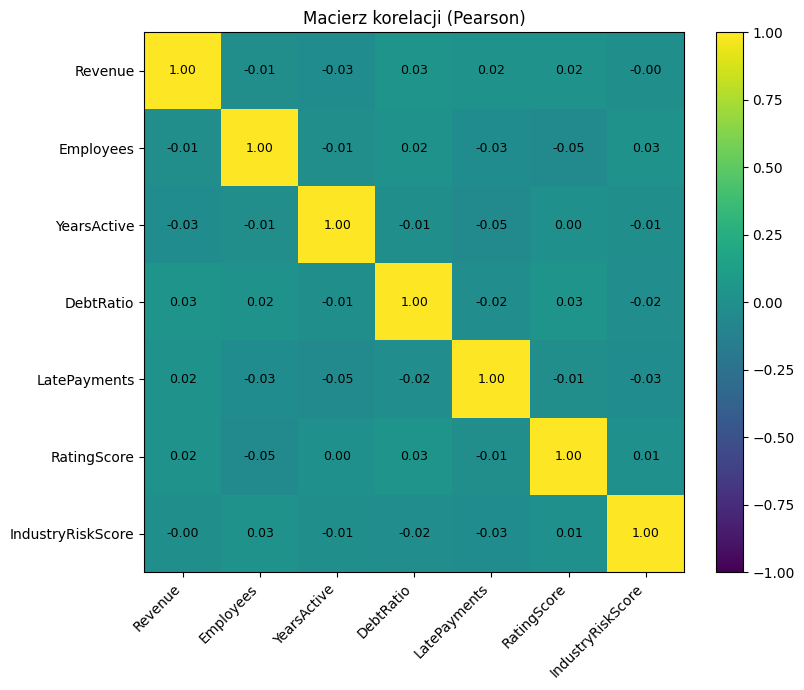

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

num_cols = [
    "Revenue",
    "Employees",
    "YearsActive",
    "DebtRatio",
    "LatePayments",
    "RatingScore",
    "IndustryRiskScore"
]

# macierz korelacji 
corr = np.array(df_model.select(num_cols).toPandas().corr())

# heatmapa
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

# liczby w komórkach
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Macierz korelacji (Pearson)")
plt.tight_layout()
plt.show()


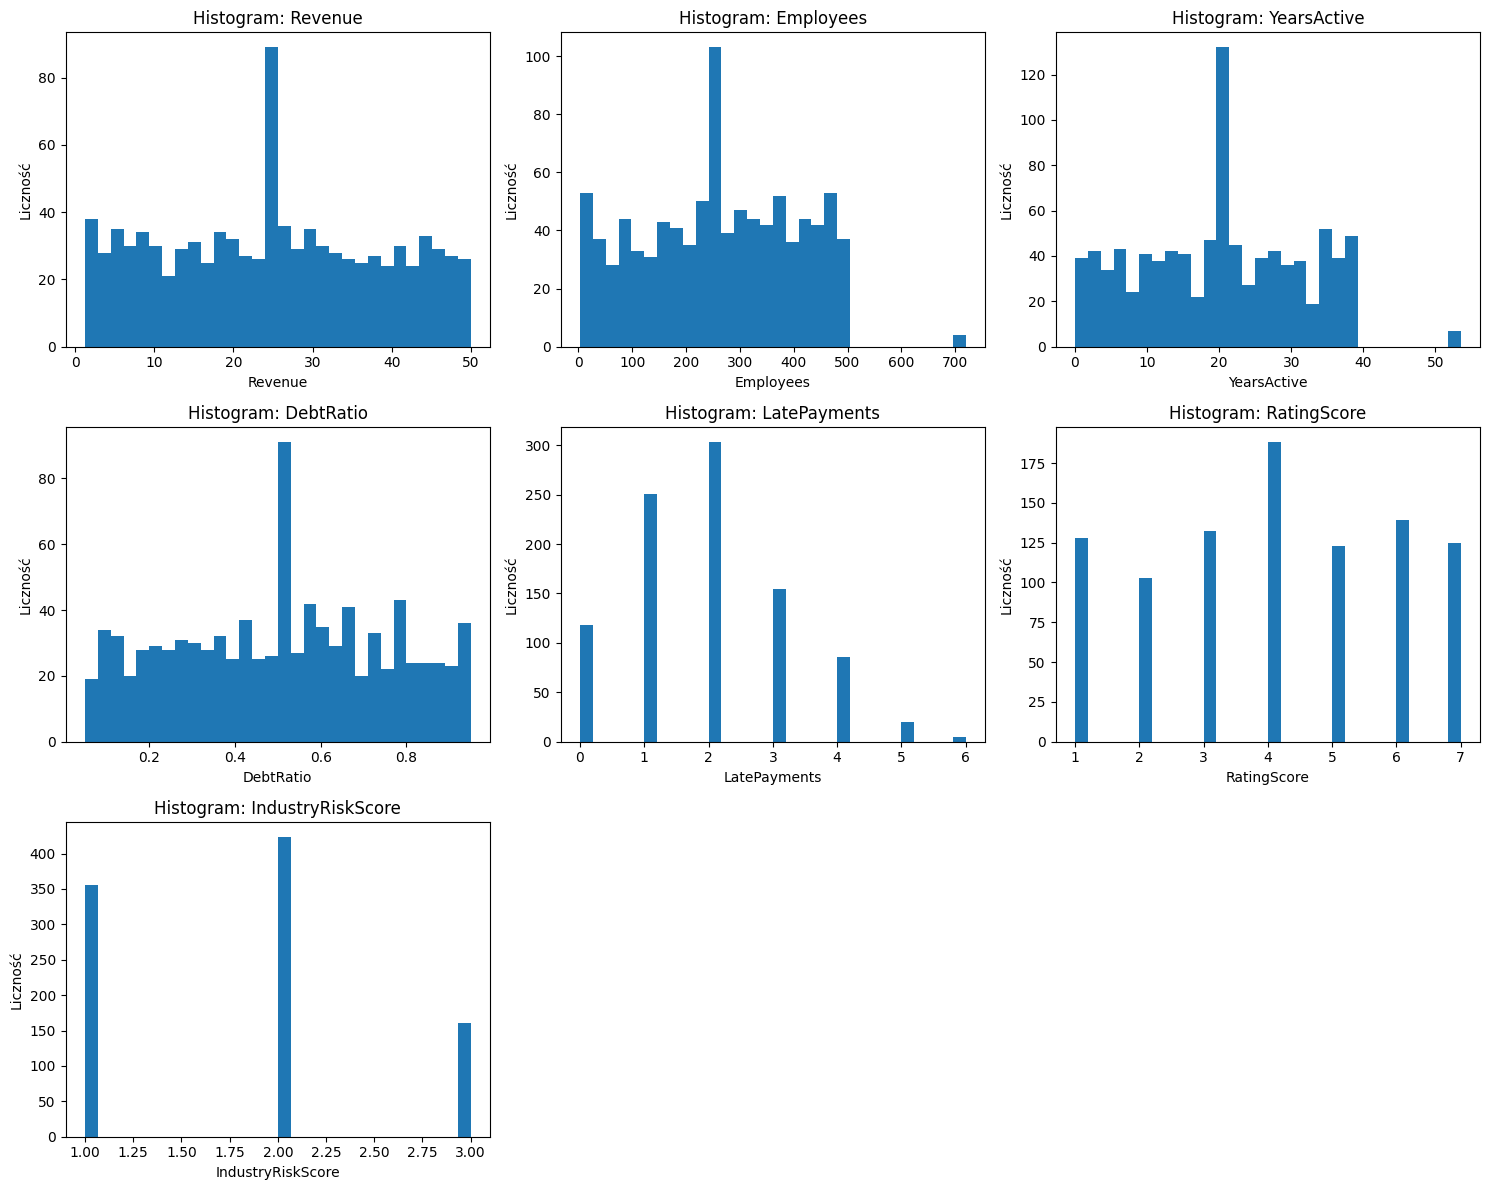

In [0]:
import math
import matplotlib.pyplot as plt

num_cols = [
    "Revenue",
    "Employees",
    "YearsActive",
    "DebtRatio",
    "LatePayments",
    "RatingScore",
    "IndustryRiskScore"
]


pdf = df_model.select(num_cols).dropna().sample(False, 1.0, seed=42).toPandas()

n = len(num_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    axes[i].hist(pdf[c], bins=30)
    axes[i].set_title(f"Histogram: {c}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Liczność")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [0]:

display(df_model)


CompanyID,Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
C0002,47.59,14.0,14.0,0.47,2.0,0,7,1,0,0,1,0,0
C0003,25.14,320.0,24.0,0.7,1.0,1,7,2,1,0,0,0,0
C0004,30.33,82.0,35.0,0.64,3.0,0,1,3,0,0,0,0,1
C0005,8.64,218.0,10.0,0.69,2.0,1,6,2,1,0,0,0,0
C0006,8.64,341.0,14.0,0.06,3.0,0,5,2,0,0,0,1,0
C0007,3.85,266.0,3.0,0.25,4.0,0,3,3,0,0,0,0,1
C0008,43.44,481.0,20.0,0.65,2.0,1,4,1,1,0,0,0,0
C0009,30.45,151.0,12.0,0.49,1.0,0,1,1,0,0,0,0,1
C0010,35.7,83.0,21.0,0.05,4.0,1,2,1,1,0,0,0,0
C0011,2.01,217.0,18.0,0.77,1.0,1,1,2,1,0,0,0,0


In [0]:
df_model.columns

['CompanyID',
 'Revenue',
 'Employees',
 'YearsActive',
 'DebtRatio',
 'LatePayments',
 'Default',
 'RatingScore',
 'IndustryRiskScore',
 'region_PL',
 'region_DE',
 'region_CZ',
 'region_SK',
 'region_OTHER']

In [0]:
from pyspark.sql import functions as F

fractions = {row["Default"]: 0.8 for row in df_model.select("Default").distinct().collect()}

train_df = df_model.sampleBy("Default", fractions=fractions, seed=42)
test_df  = df_model.subtract(train_df)

print("TRAIN rows:", train_df.count())
print("TEST rows:", test_df.count())

display(train_df.groupBy("Default").count().orderBy("Default"))
display(test_df.groupBy("Default").count().orderBy("Default"))


TRAIN rows: 785
TEST rows: 153


Default,count
0,624
1,161


Default,count
0,123
1,30


In [0]:
df_model.printSchema()

root
 |-- CompanyID: string (nullable = true)
 |-- Revenue: double (nullable = true)
 |-- Employees: double (nullable = true)
 |-- YearsActive: double (nullable = true)
 |-- DebtRatio: double (nullable = true)
 |-- LatePayments: double (nullable = true)
 |-- Default: integer (nullable = true)
 |-- RatingScore: integer (nullable = false)
 |-- IndustryRiskScore: integer (nullable = false)
 |-- region_PL: integer (nullable = true)
 |-- region_DE: integer (nullable = true)
 |-- region_CZ: integer (nullable = true)
 |-- region_SK: integer (nullable = true)
 |-- region_OTHER: integer (nullable = true)



In [0]:
from pyspark.sql import functions as F

num_cols = ["Revenue","Employees","YearsActive","DebtRatio","LatePayments","RatingScore"]

def zscore_inplace(df, means: dict, stds: dict, cols=num_cols):
    out = df
    for c in cols:
        mu = means[c]
        sd = stds[c]
        if sd is None or sd == 0:
            sd = 1.0
        out = out.withColumn(c, (F.col(c) - F.lit(mu)) / F.lit(sd))
    return out

stats = train_df.select(
    *[F.mean(c).alias(f"{c}_mean") for c in num_cols],
    *[F.stddev(c).alias(f"{c}_std") for c in num_cols]
).collect()[0]

means = {c: float(stats[f"{c}_mean"]) for c in num_cols}
stds  = {c: float(stats[f"{c}_std"])  for c in num_cols}

train_std = zscore_inplace(train_df, means, stds)
test_std  = zscore_inplace(test_df, means, stds)

display(train_std.select(num_cols + ["Default"]).limit(20))
display(test_std.select(num_cols + ["Default"]).limit(20))

Revenue,Employees,YearsActive,DebtRatio,LatePayments,RatingScore,Default
1.6508392330478676,-1.7764492148792528,-0.5483895001391472,-0.1308215241138597,0.06716660529429688,1.5195612503407876,0
0.015473717937649784,0.3854106227290136,0.32952577998572413,0.8061013707198222,-0.7317089273727193,1.5195612503407876,1
-1.1864653020765414,-0.3352093231404085,-0.8995556121890957,0.7653655926835752,0.06716660529429688,1.0022778238370935,1
-1.1864653020765414,0.5337735527609535,-0.5483895001391472,-1.8009884235999885,0.866042137961313,0.4849943973333996,0
-1.5353918418261157,0.003905945504025419,-1.5140963082765055,-1.0270086409112946,1.6649176706283293,-0.5495724556739884,0
0.402279548014944,-0.8085577189565976,-0.7239725561641215,-0.04934996804136554,-0.7317089273727193,-1.5841393086813764,0
-1.669426253754971,-0.3422742245705009,-0.19722338808919868,1.091251816973552,-0.7317089273727193,-1.5841393086813764,1
1.7193133347941305,1.5652491615544402,-0.021640332064224402,1.0097802609010578,-0.7317089273727193,-0.03228902917029438,1
1.2283394563156063,0.7810451028141866,-0.6361810281516344,0.15432892213986987,0.866042137961313,-0.03228902917029438,0
-0.9854136841832586,1.4168862315225002,-0.021640332064224402,-1.5973095334187533,-0.7317089273727193,-1.0668558821776823,0


Revenue,Employees,YearsActive,DebtRatio,LatePayments,RatingScore,Default
0.6754475071090785,-0.010223857356159329,0.06615119594826273,-0.04934996804136554,0.866042137961313,1.0022778238370935,1
0.015473717937649784,-1.0346345647195536,1.2952325881230826,0.27653625624861067,0.06716660529429688,-0.03228902917029438,0
-0.08140985155440333,-0.8226875218167823,-0.46059797212666004,-0.04934996804136554,-0.7317089273727193,-0.03228902917029438,0
-0.5330475439233721,-0.017288758786251704,-1.5140963082765055,1.8244958216259983,1.6649176706283293,1.5195612503407876,0
1.097218835950422,-1.5786319748366664,-1.07513866821407,0.9690444828648106,0.06716660529429688,-1.0668558821776823,0
-1.1245472313485376,0.7033311870831704,0.15394272396074984,-0.8640655287663065,-0.7317089273727193,-0.03228902917029438,0
-0.35530625853945524,-1.7623194120190682,0.24173425197323697,-1.149215975020036,2.4637932032953453,-1.5841393086813764,1
0.015473717937649784,-0.4553126474519789,-0.19722338808919868,-0.5789150825125772,0.06716660529429688,-0.03228902917029438,0
1.7258693658123896,0.20878808697670426,0.7684834200481597,0.7653655926835752,0.866042137961313,-0.03228902917029438,0
0.015473717937649784,0.30063180556790514,-0.46059797212666004,-1.352894865201271,0.06716660529429688,1.0022778238370935,0


In [0]:
display(train_std)
display(test_std)

CompanyID,Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
C0002,1.6508392330478676,-1.7764492148792528,-0.5483895001391472,-0.1308215241138597,0.06716660529429688,0,1.5195612503407876,1,0,0,1,0,0
C0003,0.015473717937649784,0.3854106227290136,0.32952577998572413,0.8061013707198222,-0.7317089273727193,1,1.5195612503407876,2,1,0,0,0,0
C0005,-1.1864653020765414,-0.3352093231404085,-0.8995556121890957,0.7653655926835752,0.06716660529429688,1,1.0022778238370935,2,1,0,0,0,0
C0006,-1.1864653020765414,0.5337735527609535,-0.5483895001391472,-1.8009884235999885,0.866042137961313,0,0.4849943973333996,2,0,0,0,1,0
C0007,-1.5353918418261157,0.003905945504025419,-1.5140963082765055,-1.0270086409112946,1.6649176706283293,0,-0.5495724556739884,3,0,0,0,0,1
C0009,0.402279548014944,-0.8085577189565976,-0.7239725561641215,-0.04934996804136554,-0.7317089273727193,0,-1.5841393086813764,1,0,0,0,0,1
C0011,-1.669426253754971,-0.3422742245705009,-0.19722338808919868,1.091251816973552,-0.7317089273727193,1,-1.5841393086813764,2,1,0,0,0,0
C0012,1.7193133347941305,1.5652491615544402,-0.021640332064224402,1.0097802609010578,-0.7317089273727193,1,-0.03228902917029438,2,0,1,0,0,0
C0013,1.2283394563156063,0.7810451028141866,-0.6361810281516344,0.15432892213986987,0.866042137961313,0,-0.03228902917029438,3,0,1,0,0,0
C0014,-0.9854136841832586,1.4168862315225002,-0.021640332064224402,-1.5973095334187533,-0.7317089273727193,0,-1.0668558821776823,2,0,0,0,0,1


CompanyID,Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
C0171,0.6754475071090785,-0.010223857356159329,0.06615119594826273,-0.04934996804136554,0.866042137961313,1,1.0022778238370935,1,0,1,0,0,0
C0508,0.015473717937649784,-1.0346345647195536,1.2952325881230826,0.27653625624861067,0.06716660529429688,0,-0.03228902917029438,2,0,0,0,0,1
C0287,-0.08140985155440333,-0.8226875218167823,-0.46059797212666004,-0.04934996804136554,-0.7317089273727193,0,-0.03228902917029438,1,1,0,0,0,0
C0195,-0.5330475439233721,-0.017288758786251704,-1.5140963082765055,1.8244958216259983,1.6649176706283293,0,1.5195612503407876,2,1,0,0,0,0
C0280,1.097218835950422,-1.5786319748366664,-1.07513866821407,0.9690444828648106,0.06716660529429688,0,-1.0668558821776823,2,1,0,0,0,0
C0318,-1.1245472313485376,0.7033311870831704,0.15394272396074984,-0.8640655287663065,-0.7317089273727193,0,-0.03228902917029438,3,0,1,0,0,0
C0061,-0.35530625853945524,-1.7623194120190682,0.24173425197323697,-1.149215975020036,2.4637932032953453,1,-1.5841393086813764,1,1,0,0,0,0
C0945,0.015473717937649784,-0.4553126474519789,-0.19722338808919868,-0.5789150825125772,0.06716660529429688,0,-0.03228902917029438,2,0,1,0,0,0
C0140,1.7258693658123896,0.20878808697670426,0.7684834200481597,0.7653655926835752,0.866042137961313,0,-0.03228902917029438,1,0,0,1,0,0
C0834,0.015473717937649784,0.30063180556790514,-0.46059797212666004,-1.352894865201271,0.06716660529429688,0,1.0022778238370935,3,1,0,0,0,0


In [0]:
train_std = train_std.drop("CompanyID")
test_std  = test_std.drop("CompanyID")

In [0]:
display(train_std)
display(test_std)

Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
1.6508392330478676,-1.7764492148792528,-0.5483895001391472,-0.1308215241138597,0.06716660529429688,0,1.5195612503407876,1,0,0,1,0,0
0.015473717937649784,0.3854106227290136,0.32952577998572413,0.8061013707198222,-0.7317089273727193,1,1.5195612503407876,2,1,0,0,0,0
-1.1864653020765414,-0.3352093231404085,-0.8995556121890957,0.7653655926835752,0.06716660529429688,1,1.0022778238370935,2,1,0,0,0,0
-1.1864653020765414,0.5337735527609535,-0.5483895001391472,-1.8009884235999885,0.866042137961313,0,0.4849943973333996,2,0,0,0,1,0
-1.5353918418261157,0.003905945504025419,-1.5140963082765055,-1.0270086409112946,1.6649176706283293,0,-0.5495724556739884,3,0,0,0,0,1
0.402279548014944,-0.8085577189565976,-0.7239725561641215,-0.04934996804136554,-0.7317089273727193,0,-1.5841393086813764,1,0,0,0,0,1
-1.669426253754971,-0.3422742245705009,-0.19722338808919868,1.091251816973552,-0.7317089273727193,1,-1.5841393086813764,2,1,0,0,0,0
1.7193133347941305,1.5652491615544402,-0.021640332064224402,1.0097802609010578,-0.7317089273727193,1,-0.03228902917029438,2,0,1,0,0,0
1.2283394563156063,0.7810451028141866,-0.6361810281516344,0.15432892213986987,0.866042137961313,0,-0.03228902917029438,3,0,1,0,0,0
-0.9854136841832586,1.4168862315225002,-0.021640332064224402,-1.5973095334187533,-0.7317089273727193,0,-1.0668558821776823,2,0,0,0,0,1


Revenue,Employees,YearsActive,DebtRatio,LatePayments,Default,RatingScore,IndustryRiskScore,region_PL,region_DE,region_CZ,region_SK,region_OTHER
0.6754475071090785,-0.010223857356159329,0.06615119594826273,-0.04934996804136554,0.866042137961313,1,1.0022778238370935,1,0,1,0,0,0
0.015473717937649784,-1.0346345647195536,1.2952325881230826,0.27653625624861067,0.06716660529429688,0,-0.03228902917029438,2,0,0,0,0,1
-0.08140985155440333,-0.8226875218167823,-0.46059797212666004,-0.04934996804136554,-0.7317089273727193,0,-0.03228902917029438,1,1,0,0,0,0
-0.5330475439233721,-0.017288758786251704,-1.5140963082765055,1.8244958216259983,1.6649176706283293,0,1.5195612503407876,2,1,0,0,0,0
1.097218835950422,-1.5786319748366664,-1.07513866821407,0.9690444828648106,0.06716660529429688,0,-1.0668558821776823,2,1,0,0,0,0
-1.1245472313485376,0.7033311870831704,0.15394272396074984,-0.8640655287663065,-0.7317089273727193,0,-0.03228902917029438,3,0,1,0,0,0
-0.35530625853945524,-1.7623194120190682,0.24173425197323697,-1.149215975020036,2.4637932032953453,1,-1.5841393086813764,1,1,0,0,0,0
0.015473717937649784,-0.4553126474519789,-0.19722338808919868,-0.5789150825125772,0.06716660529429688,0,-0.03228902917029438,2,0,1,0,0,0
1.7258693658123896,0.20878808697670426,0.7684834200481597,0.7653655926835752,0.866042137961313,0,-0.03228902917029438,1,0,0,1,0,0
0.015473717937649784,0.30063180556790514,-0.46059797212666004,-1.352894865201271,0.06716660529429688,0,1.0022778238370935,3,1,0,0,0,0


In [0]:
from pyspark.ml import Estimator, Model
from pyspark.ml.param.shared import Param, Params
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql import functions as F

class IQRWinsorizer(Estimator, DefaultParamsReadable, DefaultParamsWritable):
    def __init__(self, inputCols, relError=0.01, iqrFactor=1.5):
        super().__init__()
        self.inputCols = inputCols
        self.relError = relError
        self.iqrFactor = iqrFactor

    def _fit(self, dataset):
        bounds = {}
        for c in self.inputCols:
            q1, q3 = dataset.approxQuantile(c, [0.25, 0.75], self.relError)
            iqr = q3 - q1
            lower = q1 - self.iqrFactor * iqr
            upper = q3 + self.iqrFactor * iqr
            bounds[c] = (float(lower), float(upper))
        return IQRWinsorizerModel(bounds=bounds)

class IQRWinsorizerModel(Model, DefaultParamsReadable, DefaultParamsWritable):
    def __init__(self, bounds):
        super().__init__()
        self.bounds = bounds

    def _transform(self, dataset):
        out = dataset
        for c, (lower, upper) in self.bounds.items():
            out = out.withColumn(
                c,
                F.when(F.col(c) < F.lit(lower), F.lit(lower))
                 .when(F.col(c) > F.lit(upper), F.lit(upper))
                 .otherwise(F.col(c))
            )
        return out


In [0]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import SQLTransformer, Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F
from pyspark.sql.functions import col

# 0) Wczytanie danych
df = spark.table("workspace.default.credit_companies")

# 1) Konfiguracja
na_values = ["NA","na","","null"," ","-","--","?","??"]
na_sql_list = ", ".join([f"'{v}'" for v in na_values])

num_cols = ["Revenue", "Employees", "YearsActive", "DebtRatio", "LatePayments"]
cat_cols = ["Region"]  # Region robimy jako kategoria (OHE)
# IndustryRisk finalnie przerabiamy na score
target_col = "Default"

# 2) Stage: czyszczenie + label + feature engineering
# - clean numeric: na_values/litery/','->'.' cast double
# - Default_clean -> label (0/1)
# - Region/IndustryRisk whitespace+case + śmieci->OTHER/medium
# - Rating -> RatingScore (AAA..CCC) + braki -> 4
# - IndustryRiskScore (low/medium/high)

sql = f"""
SELECT
  *,

  -- label (Default_clean)
  CASE
    WHEN lower(trim(cast(`{target_col}` as string))) IN ('1','yes') THEN 1.0
    WHEN lower(trim(cast(`{target_col}` as string))) IN ('0','no')  THEN 0.0
    ELSE NULL
  END AS label,

  -- czyszczenie numericów
  CASE
    WHEN cast(Revenue as string) IN ({na_sql_list}) THEN NULL
    WHEN cast(Revenue as string) RLIKE '.*[A-Za-z].*' THEN NULL
    ELSE CAST(REPLACE(cast(Revenue as string), ',', '.') AS DOUBLE)
  END AS Revenue_clean,

  CASE
    WHEN cast(YearsActive as string) IN ({na_sql_list}) THEN NULL
    WHEN cast(YearsActive as string) RLIKE '.*[A-Za-z].*' THEN NULL
    ELSE CAST(REPLACE(cast(YearsActive as string), ',', '.') AS DOUBLE)
  END AS YearsActive_clean,

  CASE
    WHEN cast(DebtRatio as string) IN ({na_sql_list}) THEN NULL
    WHEN cast(DebtRatio as string) RLIKE '.*[A-Za-z].*' THEN NULL
    ELSE CAST(REPLACE(cast(DebtRatio as string), ',', '.') AS DOUBLE)
  END AS DebtRatio_clean,

  CASE
    WHEN cast(Employees as string) IN ({na_sql_list}) THEN NULL
    WHEN cast(Employees as string) RLIKE '.*[A-Za-z].*' THEN NULL
    ELSE CAST(REPLACE(cast(Employees as string), ',', '.') AS DOUBLE)
  END AS Employees_clean,

  CASE
    WHEN cast(LatePayments as string) IN ({na_sql_list}) THEN NULL
    WHEN cast(LatePayments as string) RLIKE '.*[A-Za-z].*' THEN NULL
    ELSE CAST(REPLACE(cast(LatePayments as string), ',', '.') AS DOUBLE)
  END AS LatePayments_clean,

  -- Region normalize + śmieci -> OTHER
  CASE
    WHEN upper(regexp_replace(trim(cast(Region as string)), '\\\\s+', ' ')) IS NULL THEN 'OTHER'
    WHEN upper(regexp_replace(trim(cast(Region as string)), '\\\\s+', ' ')) IN ('', 'NA', 'UNKNOWN', '?', 'N/A') THEN 'OTHER'
    ELSE upper(regexp_replace(trim(cast(Region as string)), '\\\\s+', ' '))
  END AS Region_norm,

  -- IndustryRisk normalize + śmieci -> medium
  CASE
    WHEN lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' ')) IS NULL THEN 'medium'
    WHEN lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' ')) IN ('', 'na', 'unknown', '?', 'n/a') THEN 'medium'
    ELSE lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' '))
  END AS IndustryRisk_norm,

  -- IndustryRiskScore
  CASE
    WHEN lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' ')) = 'low' THEN 1
    WHEN lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' ')) = 'medium' THEN 2
    WHEN lower(regexp_replace(trim(cast(IndustryRisk as string)), '\\\\s+', ' ')) = 'high' THEN 3
    ELSE 2
  END AS IndustryRiskScore,

  -- RatingScore (AAA..CCC) + default 4
  COALESCE(
    CASE upper(regexp_replace(trim(cast(Rating as string)), '\\\\s+', ' '))
      WHEN 'AAA' THEN 7
      WHEN 'AA'  THEN 6
      WHEN 'A'   THEN 5
      WHEN 'BBB' THEN 4
      WHEN 'BB'  THEN 3
      WHEN 'B'   THEN 2
      WHEN 'CCC' THEN 1
      ELSE NULL
    END, 4
  ) AS RatingScore

FROM __THIS__
"""

stage_clean = SQLTransformer(statement=sql)

# 3) Stage: wybór “finalnych” kolumn numerycznych (używamy *_clean zamiast surowych)

stage_select = SQLTransformer(statement="""
SELECT
  -- label
  label,

  -- numeryczne final
  Revenue_clean    AS Revenue,
  Employees_clean  AS Employees,
  YearsActive_clean AS YearsActive,
  DebtRatio_clean  AS DebtRatio,
  LatePayments_clean AS LatePayments,
  CAST(RatingScore AS DOUBLE) AS RatingScore,
  CAST(IndustryRiskScore AS DOUBLE) AS IndustryRiskScore,

  -- kategoria
  Region_norm AS Region

FROM __THIS__
""")

final_num = ["Revenue","Employees","YearsActive","DebtRatio","LatePayments","RatingScore","IndustryRiskScore"]

# 4) Imputer medianą 
imputer = Imputer(strategy="median", inputCols=final_num, outputCols=[c+"_imp" for c in final_num])

# 5) Winsoryzacja outlierów IQR
winsor = IQRWinsorizer(inputCols=[c+"_imp" for c in final_num], relError=0.01, iqrFactor=1.5)

# 6) Region: StringIndexer + OHE
region_indexer = StringIndexer(inputCol="Region", outputCol="Region_idx", handleInvalid="keep")
region_ohe = OneHotEncoder(inputCol="Region_idx", outputCol="Region_oh", handleInvalid="keep")

# 7) Assembler
feature_cols = [c+"_imp" for c in final_num] + ["Region_oh"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# 8) StandardScaler = Z-score 
scaler = StandardScaler(inputCol="features", outputCol="features_scaled", withStd=True, withMean=False)

# 9) Model
lr = LogisticRegression(featuresCol="features_scaled", labelCol="label", maxIter=100, regParam=0.0, elasticNetParam=0.0)

pipeline = Pipeline(stages=[
    stage_clean,
    stage_select,
    imputer,
    winsor,
    region_indexer,
    region_ohe,
    assembler,
    scaler,
    lr
])


In [0]:
data = df  

tmp = Pipeline(stages=[stage_clean, stage_select]).fit(data).transform(data).where(col("label").isNotNull())

fractions = {float(row["label"]): 0.8 for row in tmp.select("label").distinct().collect()}

train_raw = tmp.withColumn("label", col("label").cast("double")) \
               .sampleBy("label", fractions=fractions, seed=42)
test_raw  = tmp.subtract(train_raw)

# teraz uczymy już pełny pipeline na TRAIN (bez wycieku)
model = Pipeline(stages=[
    imputer, winsor, region_indexer, region_ohe, assembler, scaler, lr
]).fit(train_raw)

pred = model.transform(test_raw)

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(pred)
acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(pred)
f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(pred)

print(f"AUC={auc:.4f}  ACC={acc:.4f}  F1={f1:.4f}")
pred.groupBy("label","prediction").count().orderBy("label","prediction").show()


AUC=0.4843  ACC=0.8039  F1=0.7165
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  123|
|  1.0|       0.0|   30|
+-----+----------+-----+



In [0]:
pred.select(
    "label",
    "Revenue","Employees","YearsActive","DebtRatio","LatePayments","RatingScore","IndustryRiskScore",
    "Region",
    "features", "features_scaled",
    "probability","prediction","rawPrediction"
).show(20, truncate=False)

+-----+-------+---------+-----------+---------+------------+-----------+-----------------+------+-----------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+----------+----------------------------------------+
|label|Revenue|Employees|YearsActive|DebtRatio|LatePayments|RatingScore|IndustryRiskScore|Region|features                                                   |features_scaled                                                                                                                                                               |probability                             |prediction|rawPrediction                           |
+-----+-------+---------+-----------+---------+------------+-----------+-----------------+------+---------------------------------------------------

In [0]:
display(pred.limit(50))

pred.show(50, truncate=False)

pred.printSchema()

label,Revenue,Employees,YearsActive,DebtRatio,LatePayments,RatingScore,IndustryRiskScore,Region,Revenue_imp,Employees_imp,YearsActive_imp,DebtRatio_imp,LatePayments_imp,RatingScore_imp,IndustryRiskScore_imp,Region_idx,Region_oh,features,features_scaled,rawPrediction,probability,prediction
0.0,27.43,238.0,1.0,0.61,1.0,4.0,3.0,OTHER,27.43,238.0,1.0,0.61,1.0,4.0,3.0,2.0,"{""type"":""0"",""size"":""6"",""indices"":[""2""],""values"":[""1.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""27.43"",""238.0"",""1.0"",""0.61"",""1.0"",""4.0"",""3.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.9981502660455437"",""1.682041029248258"",""0.0877915280124872"",""2.4844000696509436"",""0.7988755326670158"",""2.0691337060147763"",""4.255688305888819"",""0.0"",""0.0"",""2.664055335355353"",""0.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.262964543676342"",""-1.262964543676342""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7795360153033346"",""0.2204639846966654""]}",0.0
1.0,37.97,369.0,30.0,0.3,0.0,6.0,1.0,PL,37.97,369.0,30.0,0.3,0.0,6.0,1.0,0.0,"{""type"":""0"",""size"":""6"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""13"",""indices"":[""0"",""1"",""2"",""3"",""5"",""6"",""7""],""values"":[""37.97"",""369.0"",""30.0"",""0.3"",""6.0"",""1.0"",""1.0""]}","{""type"":""0"",""size"":""13"",""indices"":[""0"",""1"",""2"",""3"",""5"",""6"",""7""],""values"":[""2.765941144795818"",""2.6078703352630552"",""2.633745840374616"",""1.221836099828333"",""3.1037005590221645"",""1.4185627686296063"",""2.004015701770707""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.066594598011889"",""-1.066594598011889""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7439487632800731"",""0.2560512367199269""]}",0.0
0.0,14.27,47.0,null,0.81,5.0,5.0,1.0,SK,14.27,47.0,20.0,0.81,5.0,5.0,1.0,3.0,"{""type"":""0"",""size"":""6"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""14.27"",""47.0"",""20.0"",""0.81"",""5.0"",""5.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0395043491239484"",""0.3321677662801182"",""1.755830560249744"",""3.2989574695364996"",""3.9943776633350794"",""2.5864171325184704"",""1.4185627686296063"",""0.0"",""0.0"",""0.0"",""3.4201267355377793"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""2.01623300318429"",""-2.01623300318429""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.8824909314667959"",""0.11750906853320409""]}",0.0
0.0,9.91,200.0,26.0,0.74,4.0,2.0,2.0,DE,9.91,200.0,26.0,0.74,4.0,2.0,2.0,1.0,"{""type"":""0"",""size"":""6"",""indices"":[""1""],""values"":[""1.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""9.91"",""200.0"",""26.0"",""0.74"",""4.0"",""2.0"",""2.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7218982550678578"",""1.413479856511141"",""2.2825797283246674"",""3.0138623795765547"",""3.1955021306680633"",""1.0345668530073882"",""2.8371255372592126"",""0.0"",""2.5752468914114113"",""0.0"",""0.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.8748250887984275"",""-1.8748250887984275""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.867015593913274"",""0.13298440608672601""]}",0.0
1.0,40.12,58.0,8.0,0.42,3.0,4.0,2.0,DE,40.12,58.0,8.0,0.42,3.0,4.0,2.0,1.0,"{""type"":""0"",""size"":""6"",""indices"":[""1""],""values"":[""1.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""40.12"",""58.0"",""8.0"",""0.42"",""3.0"",""4.0"",""2.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""0.0""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""2.9225588287913675"",""0.40990915

+-----+-------+---------+-----------+---------+------------+-----------+-----------------+------+-----------+-------------+---------------+-------------+----------------+---------------+---------------------+----------+-------------+-----------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+----------------------------------------+----------+
|label|Revenue|Employees|YearsActive|DebtRatio|LatePayments|RatingScore|IndustryRiskScore|Region|Revenue_imp|Employees_imp|YearsActive_imp|DebtRatio_imp|LatePayments_imp|RatingScore_imp|IndustryRiskScore_imp|Region_idx|Region_oh    |features                                                   |features_scaled                                                                                                                                  